In [1]:
#!pip install yfinance
# Thêm các thư viện cần thiết
import pandas as pd
from pandas_datareader import data as pdr
import numpy as np
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from tensorflow.keras.models import Model
from keras.layers import LSTM, Dense, Bidirectional, Dropout, Input, Concatenate
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import History
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Activation
from keras.layers import Conv1D, MaxPooling1D, Flatten, AveragePooling1D
!pip install keras-self-attention
from keras_self_attention import SeqSelfAttention
from tensorflow.keras.layers import MultiHeadAttention
!pip install attention
from attention import Attention

  Preparing metadata (setup.py) ... done
  Created wheel for keras-self-attention: filename=keras_self_attention-0.51.0-py3-none-any.whl size=18894 sha256=ac76b285456b9e8ef43c8c872fe9b2d23a503135553fee30ccdb137eebd12978
  Stored in directory: /root/.cache/pip/wheels/b8/f7/24/607b483144fb9c47b4ba2c5fba6b68e54aeee2d5bf6c05302e
Successfully built keras-self-attention


In [2]:
data_ORCL = pd.read_csv('ORCL.csv')

data_ORCL

,Date,Close,Open,High,Low,Adj Close,Volume
0,2019-12-31,52.980000,52.570000,53.000000,52.549999,49.155796,7094500
1,2020-01-02,53.950001,53.270000,53.959999,53.230000,50.055779,13899600
2,2020-01-03,53.759998,52.990002,54.049999,52.950001,49.879490,11026700
3,2020-01-06,54.040001,53.360001,54.200001,53.349998,50.139278,10982400
4,2020-01-07,54.160000,53.889999,54.330002,53.610001,50.250622,12015400
...,...,...,...,...,...,...,...
1105,2024-05-22,124.599998,124.629997,125.160004,123.300003,124.249191,5705000
1106,2024-05-23,124.089996,126.550003,126.699997,123.160004,123.740623,6108600
1107,2024-05-24,122.910004,123.419998,123.510002,121.419998,122.563950,7166100
1108,2024-05-28,124.489998,123.239998,124.820000,123.010002,124.139496,6911400


In [3]:
data = data_ORCL
epoch = 500
#columns = ['Close']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume']
#columns = ['Close', 'Open', 'High', 'Low', 'Adj Close']
columns = ['Close', 'Open', 'High', 'Low']
#columns = ['Close', 'MACD', 'MFI', 'RSI', 'ATR']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR', 'USD/VND', 'IR', 'CFI', 'Broad money M2']
#columns = ['Close', 'Open', 'High', 'Low', 'Volume', 'MACD', 'MFI', 'RSI', 'ATR', 'USD/VND', 'IR', 'CFI']

data = data[columns]

train_size = int(len(data) * 0.9)

train = data[:train_size]
test = data['Close']
test = data[train_size:]

train = train[columns]

scaler = MinMaxScaler(feature_range = (0, 1))

# train_scaled = scaler.fit_transform(train)
# test_scaled = scaler.transform(data)
scaled = scaler.fit_transform(data)
train_scaled = scaled[:int(train_size)]

test_data_lb_7day = scaled[int(train_size) - 7: , :]
test_data_lb_14day = scaled[int(train_size) - 14: , :]
test_data_lb_21day = scaled[int(train_size) - 21: , :]

In [4]:
def create_cnn_bilstm_branch(input_layer, units, dropout_rate):
    cnn = Conv1D(filters=64, kernel_size=3, padding = 'same', activation='relu')(input_layer)
    cnn = Conv1D(filters=128, kernel_size=3, padding = 'same', activation='relu')(cnn)
    cnn = Conv1D(filters=64, kernel_size=3, padding = 'same', activation='relu')(cnn)
    #cnn = MaxPooling1D(pool_size=2)(cnn)
    cnn = AveragePooling1D(pool_size=2)(cnn)

    bilstm = Bidirectional(LSTM(units=units, return_sequences=True))(cnn)
    #bilstm = Dropout(dropout_rate)(bilstm)

    #bilstm = Bidirectional(LSTM(units=units, return_sequences=True))(bilstm)
    #bilstm = Dropout(dropout_rate)(bilstm)


    #bilstm = Dropout(dropout_rate)(bilstm)

    bilstm = SeqSelfAttention(attention_activation='elu')(bilstm)
    #bilstm = Attention(units=units)(bilstm)

    return bilstm

def parallel_cnn_bilstm_model(train_scaled, test_scaled, lb, batchsize):
    X_train = []
    Y_train = []

    for i in range(lb, len(train_scaled)):
        X_train.append(train_scaled[i - lb:i, :])
        Y_train.append(train_scaled[i, 0])

    X_train, Y_train = np.array(X_train), np.array(Y_train)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(columns)))
    x_train, x_val, y_train, y_val = train_test_split(X_train, Y_train, test_size=0.1)

    start_time = time.time()
    history = History()
    early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

    input_layer = Input(shape=(x_train.shape[1], x_train.shape[2]))

    cnn_bilstm1 = create_cnn_bilstm_branch(input_layer, units=128, dropout_rate=0.3)
    cnn_bilstm2 = create_cnn_bilstm_branch(input_layer, units=128, dropout_rate=0.3)

    concatenated = Concatenate()([cnn_bilstm1, cnn_bilstm2])

    concatenated = Flatten()(concatenated)

    dense = Dense(units=128, activation='sigmoid')(concatenated)
    output = Dense(units=1)(dense)

    model = Model(inputs=input_layer, outputs=output)

    # Compile the model
    model.compile(optimizer='adam', loss='mse')
    # Train the model
    model.fit(x_train, y_train, epochs=epoch, validation_data=(x_val, y_val),
              batch_size=batchsize, callbacks=[history, early_stopping])

    end_time = time.time()
    training_time = end_time - start_time

    loss = history.history['loss']
    val_loss = history.history['val_loss']
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    x_test = []
    for i in range(lb, len(test_scaled)):
      x_test.append(test_scaled[i - lb:i, :])
    x_test = np.array(x_test)
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], len(columns)))

    predictions = model.predict(x_test)
    predictions = predictions.reshape(-1, 1)
    X = np.random.rand(int(len(test)), int(len(columns) - 1))
    predictions = np.hstack((predictions, X))
    predictions = scaler.inverse_transform(predictions)

    return predictions[:, 0], training_time

Epoch 1/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - loss: 0.0721 - val_loss: 0.0246
Epoch 2/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0128 - val_loss: 0.0055
Epoch 3/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0043 - val_loss: 0.0017
Epoch 4/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 5/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0016 - val_loss: 0.0013
Epoch 6/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 7/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0013 - val_loss: 8.4074e-04
Epoch 8/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0010 - val_loss: 9.1803e-04
Epoch 9/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 9.4854e-04 - val_loss: 8.3813e-04
Epoch 10/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0011 - val_loss: 8.8529e-04
Epoch 11/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0011 - val_loss: 7.9765e-04
Epoch 12/500
14/14 ━━━━━━━━━

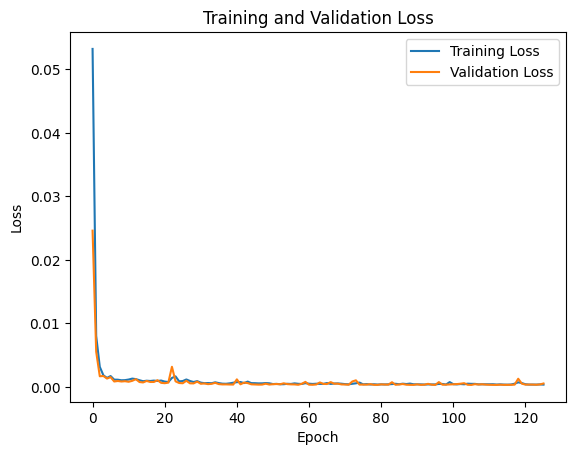

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 174ms/step


In [16]:
predictions_lb_7day, training_time_lb_7day = parallel_cnn_bilstm_model(train_scaled, test_data_lb_7day, 7, 64)

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - loss: 0.0766 - val_loss: 0.0238
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0127 - val_loss: 0.0086
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0085 - val_loss: 0.0020
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0019 - val_loss: 0.0035
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0025 - val_loss: 0.0017
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0017 - val_loss: 0.0019
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0015 - val_loss: 0.0020
Epoch 9/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 10/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 11/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0014 - val_loss: 0.0021
Epoch 12/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0014 - val_l

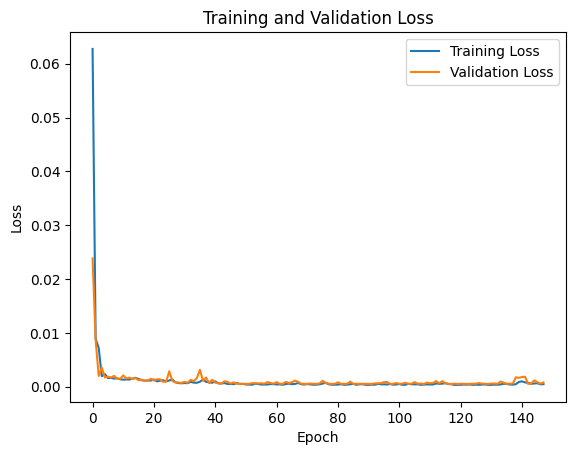

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step


In [24]:
predictions_lb_14day, training_time_lb_14day = parallel_cnn_bilstm_model(train_scaled, test_data_lb_14day, 14, 128)

Epoch 1/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 0.1891 - val_loss: 0.0024
Epoch 2/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 3/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0029 - val_loss: 0.0021
Epoch 4/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 5/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0022 - val_loss: 0.0014
Epoch 6/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0022 - val_loss: 0.0026
Epoch 7/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0029 - val_loss: 0.0015
Epoch 8/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 9/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0019 - val_loss: 0.0011
Epoch 10/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0013 - val_loss: 0.0013
Epoch 11/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 12/500
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

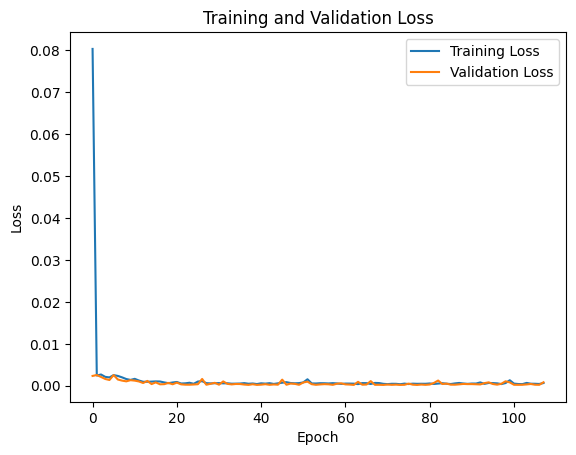

1/4 ━━━━━━━━━━━━━━━━━━━━ 1s 498ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step


In [7]:
predictions_lb_21day, training_time_lb_21day = parallel_cnn_bilstm_model(train_scaled, test_data_lb_21day, 21, 96)

In [25]:
data_visual = data_ORCL.filter(['Date', 'Close'])
data_visual['Date'] = pd.to_datetime(data_visual['Date'])
valid = data_visual[train_size:]

valid['Predictions lb 7 day'] = predictions_lb_7day
valid['Predictions lb 14 day'] = predictions_lb_14day
valid['Predictions lb 21 day'] = predictions_lb_21day

valid

<ipython-input-25-33984e91cc03>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions lb 7 day'] = predictions_lb_7day
<ipython-input-25-33984e91cc03>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions lb 14 day'] = predictions_lb_14day
<ipython-input-25-33984e91cc03>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

,Date,Close,Predictions lb 7 day,Predictions lb 14 day,Predictions lb 21 day
999,2023-12-19,106.250000,105.845558,105.745026,105.700938
1000,2023-12-20,104.150002,106.635059,106.838241,106.730852
1001,2023-12-21,105.860001,105.699610,105.763956,105.550912
1002,2023-12-22,106.199997,106.024345,105.887066,106.538977
1003,2023-12-26,106.190002,106.661751,106.574685,106.614065
...,...,...,...,...,...
1105,2024-05-22,124.599998,124.539958,124.261625,124.292156
1106,2024-05-23,124.089996,124.364802,123.993415,124.012761
1107,2024-05-24,122.910004,124.804666,124.181355,124.261854
1108,2024-05-28,124.489998,122.619862,122.053071,122.487673


In [26]:
def calculateAccurary(prediction, close):

  mse = mean_squared_error(close, prediction)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(close, prediction)
  mape = mean_absolute_percentage_error(close, prediction)
  r2 = r2_score(close, prediction)

  print("RMSE:", round(rmse, 5))
  print("MSE :", round(mse, 5))
  print("MAE :", round(mae, 5))
  print("MAPE:", round(mape, 5))
  print("R^2 :", round(r2, 5))
  print()

print("CNN-Bi LSTM Lb 7 day")
print("Training time CNN-Bi LSTM:", round(training_time_lb_7day, 2), "seconds", "=", round(training_time_lb_7day/60, 2), "minutes")
calculateAccurary(valid['Predictions lb 7 day'], valid["Close"])

print("CNN-Bi LSTM Lb 14 day")
print("Training time CNN-Bi LSTM:", round(training_time_lb_14day, 2), "seconds", "=", round(training_time_lb_14day/60, 2), "minutes")
calculateAccurary(valid['Predictions lb 14 day'], valid["Close"])

print("CNN-Bi LSTM Lb 21 day")
print("Training time CNN-Bi LSTM:", round(training_time_lb_21day, 2), "seconds", "=", round(training_time_lb_21day/60, 2), "minutes")
calculateAccurary(valid['Predictions lb 21 day'], valid["Close"])

CNN-Bi LSTM Lb 7 day
Training time CNN-Bi LSTM: 49.96 seconds = 0.83 minutes
RMSE: 1.99614
MSE : 3.98456
MAE : 1.28646
MAPE: 0.01105
R^2 : 0.92373

CNN-Bi LSTM Lb 14 day
Training time CNN-Bi LSTM: 40.46 seconds = 0.67 minutes
RMSE: 2.01485
MSE : 4.05963
MAE : 1.2743
MAPE: 0.01092
R^2 : 0.92229

CNN-Bi LSTM Lb 21 day
Training time CNN-Bi LSTM: 70.9 seconds = 1.18 minutes
RMSE: 1.94455
MSE : 3.78126
MAE : 1.25722
MAPE: 0.01078
R^2 : 0.92762



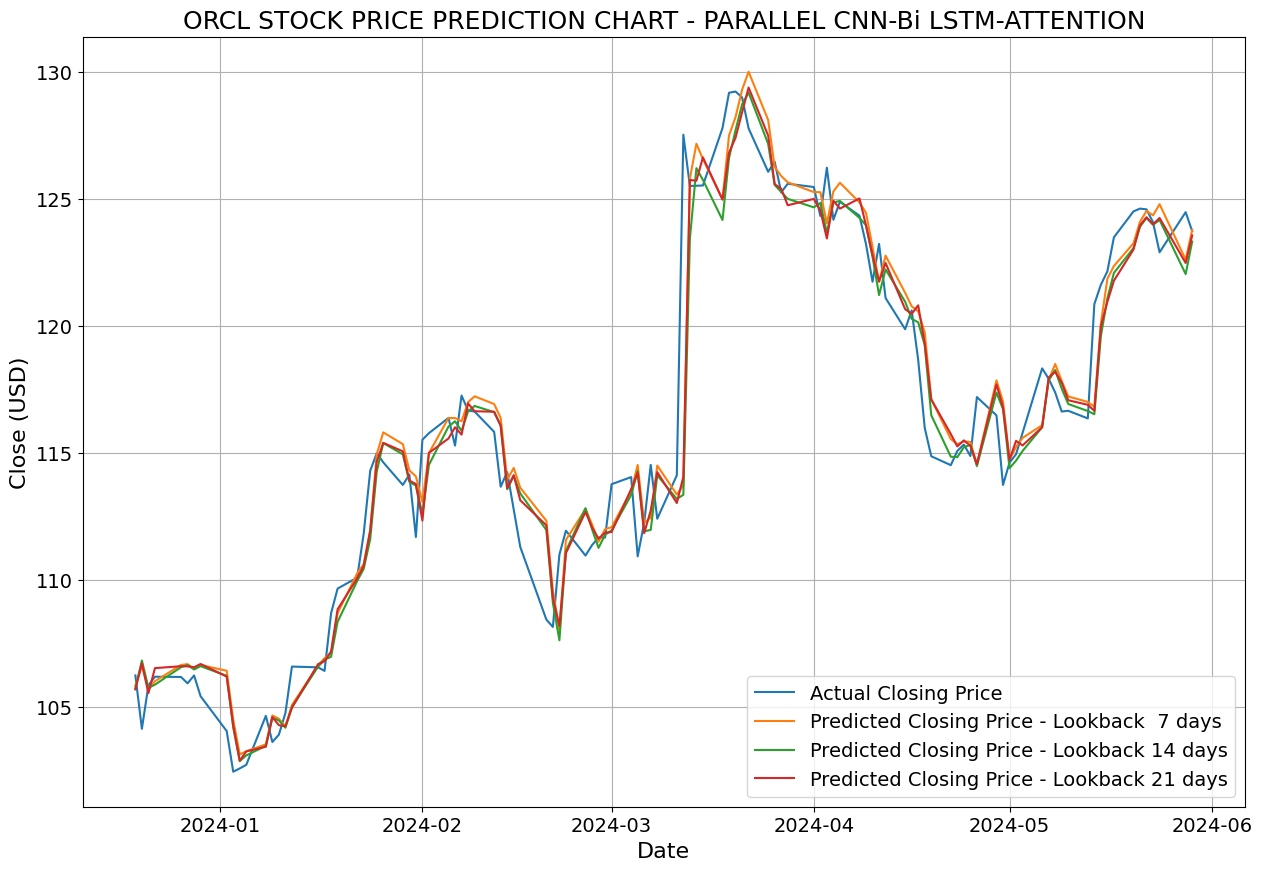

In [27]:
# Draw a historial of closing price
plt.figure(figsize=(15, 10))

plt.plot(valid['Date'], valid['Close'])
plt.plot(valid['Date'], valid['Predictions lb 7 day'])
plt.plot(valid['Date'], valid['Predictions lb 14 day'])
plt.plot(valid['Date'], valid['Predictions lb 21 day'])
plt.ylabel('Close (USD)', fontsize=16)
plt.ylabel('Close (USD)', fontsize=16)
plt.xlabel('Date', fontsize=16)
plt.title(f"ORCL STOCK PRICE PREDICTION CHART - PARALLEL CNN-Bi LSTM-ATTENTION", fontsize=18)
plt.legend(['Actual Closing Price', 'Predicted Closing Price - Lookback  7 days',
            'Predicted Closing Price - Lookback 14 days', 'Predicted Closing Price - Lookback 21 days'], loc='lower right', fontsize=14)
plt.grid(True)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.show()
